In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

# import nozzel2 as nz


# Parameters
f = 600   # N
pc = 2.468e6 # mpa - pa (e6) Chamber pressure
pe = 0.1e6 # mpa - pa (e6)   exit pressure
tc = 2800  # K  - Chamber Tempreture
y = 1.3    # or K Specific heat ratio
r = 355.4    # J/Kgh   gas constant
pi = np.pi
ε = 5.23

# p0 = np.mpa * nz.e6
# print(f"po is {p0}")

# angles
divergent_angle = 15 #(12 - 18)
convergent_a = 30 #(30 - 45)

da = np.radians(divergent_angle)
ca = np.radians(convergent_a)

# characteristic length
length = 0.7 #(0.5 - 1)M

# Exit velocity
ve = np.sqrt((2*y/(y-1))*r*tc*(1-(pe/pc)**((y-1)/y)))
print(f"Exit velocity: {ve:.2f} m/s")

# mass flow
m = f/ve
print(f"Mass flow rate: {m:.4f} kg/s")

# throat area
at = (m/pc)* np.sqrt( ((r*tc) / y) * (((y+1) / 2)**((y+1) / (2*(y-1)))))
print(f"Area of throat: {at:.6f} m^2")

# throat diameter
dt = np.sqrt((4*at)/pi)

# exit area
ae = ε*at
de = np.sqrt((4*ae)/pi)

# chamber diameter
cd = 3*dt

# chamber area
ac = (pi*(cd**2))/4

# chamber length
lc = (length*at)/ac

# convergent length
convergent_length = (cd-dt)/(2*np.tan(ca))

# divergent length
divergent_length = (de-dt)/(2*np.tan(da))

# total length
total_length = lc + convergent_length + divergent_length

# convert to mm
dt_mm = dt*1000
de_mm = de*1000
cd_mm = cd*1000
lc_mm = lc*1000
conv_mm = convergent_length*1000
div_mm = divergent_length*1000
total_mm = total_length*1000

print(f"Chamber diameter: {cd_mm:.2f} mm")
print(f"Chamber length: {lc_mm:.2f} mm")
print(f"Convergent length: {conv_mm:.2f} mm")
print(f"Throat diameter: {dt_mm:.2f} mm")
print(f"Divergent length: {div_mm:.2f} mm")
print(f"Exit diameter: {de_mm:.2f} mm")
print(f"Total length: {total_mm:.2f} mm")

Exit velocity: 2123.42 m/s
Mass flow rate: 0.2826 kg/s
Area of throat: 0.000131 m^2
Chamber diameter: 38.74 mm
Chamber length: 77.78 mm
Convergent length: 22.36 mm
Throat diameter: 12.91 mm
Divergent length: 31.01 mm
Exit diameter: 29.53 mm
Total length: 131.15 mm


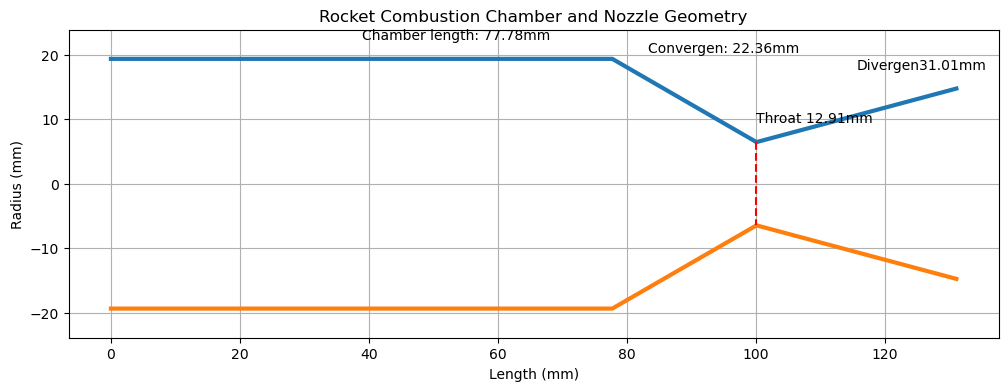

In [2]:
# Convert to radius 
rc = cd_mm / 2
rt = dt_mm / 2
re = de_mm / 2

# X positions
x0 = 0
x1 = lc_mm
x2 = x1 + conv_mm
x3 = x2 + div_mm

#  Upper wall profile 
x_upper = [x0, x1, x2, x3]
y_upper = [rc, rc, rt, re]

# Lower wall profile (mirror)
y_lower = [-y for y in y_upper]

#  Plot 
plt.figure(figsize=(12,4))

plt.plot(x_upper, y_upper, linewidth=3)
plt.plot(x_upper, y_lower, linewidth=3)

# throat marker
plt.plot([x2,x2],[rt,-rt],'r--')

plt.title("Rocket Combustion Chamber and Nozzle Geometry")
plt.xlabel("Length (mm)")
plt.ylabel("Radius (mm)")
plt.axis("equal")
plt.grid(True)

# Labels
plt.text(lc_mm/2, rc+3, f"Chamber length: {lc_mm:.2f}mm")
plt.text(x1+conv_mm/4, rc+1, f"Convergen: {conv_mm:.2f}mm")
plt.text(x2, rt+3, f"Throat {dt_mm:.2f}mm")
plt.text(x2+div_mm/2, re+3,f"Divergen{div_mm:.2f}mm")

plt.show()


In [3]:
import math

def get_atmosphere_data(h):
    """
    Calculates atmospheric properties based on altitude (h) in meters.
    Returns: temperature (C), pressure (kPa), density (kg/m³)
    """

    if h < 11000:
        # Troposphere
        temp = 15.04 - 0.00649 * h
        pressure = 101.29 * ((temp + 273.1) / 288.08)**5.256

    elif 11000 <= h <= 25000:
        # Lower Stratosphere
        temp = -56.46
        pressure = 22.65 * math.exp(1.73 - 0.000157 * h)

    else:
        # Upper Stratosphere
        temp = -131.21 + 0.00299 * h
        pressure = 2.488 * ((temp + 273.1) / 216.6)**-11.388

    density = pressure / (0.2869 * (temp + 273.1))

    return temp, pressure, density


# Example
Target_height = 10 #KM
altitude = Target_height * 1000   # Requuired KM of rocket

t, p, rho = get_atmosphere_data(altitude)

temp_k = t + 273.15
pressure_pa = p * 1000
pressure_mpa = pressure_pa / 1e6

print(f"Altitude: {altitude} m")
print(f"Temperature: {t:.2f} °C")
print(f"Temperature: {temp_k:.2f} K")
print(f"Pressure: {p:.2f} kPa")
print(f"Pressure: {pressure_pa:.2f} Pa")
print(f"Pressure: {pressure_mpa:.6f} MPa")
print(f"Density: {rho:.4f} kg/m³")

Altitude: 10000 m
Temperature: -49.86 °C
Temperature: 223.29 K
Pressure: 26.52 kPa
Pressure: 26516.21 Pa
Pressure: 0.026516 MPa
Density: 0.4140 kg/m³


In [4]:

#Envinomental values

pa = pressure_pa   # for 10Km Alititude
ta = temp_k   # for 10Km Alititude


#Throat Radius
Trs = 3.6837
tr = (2*Trs)/1000


#Exit Radius
Er = 0.0807
er = (Er*2)/1000

# Chamber pressure
cp = pc

# Chamber tempreture
ct = tc

#outside air pressure and tempreture
p = 24.5
t = 245

# Calculations

# Mass flow
ms = m

# Nozzle area ratio
ar = ae/at
print(f"Nozzle area ratio: {ar}")

# Stagnation Density
ρ0 = pc / (r * tc)
print(f"Stagnation Density: {ρ0:.2f} kg/m^3")

# Throart Velocity (where mach = 1)
vt = np.sqrt( (2*y*r*tc) / (y+1) )
print(f"Throart Velocity: {vt:.2f} m/s")

# Exit Mach
me = np.sqrt((2/(y-1))*((pc/pe)**((y-1)/y)-1))
print(f"Exit Mach number: {me:.2f} ")

# Throat Density
ρt = ρ0 * (2/(y+1))**(1/(y-1))
print(f"Throat density: {ρt:.2f} kg/m^3")

#Exit Pressure
ep = pc / (1+((y-1)/2)*(me**2))**(y/(y-1))
print(f"Exit Pressure: {ep:.2f} pa")

# Exit Tempreture
et = tc / (1 + (((y-1)/2) * (me**2)))
print(f"Exit Tempreture: {et:.2f} K")

# Exit Vlecity 
v_e = me * np.sqrt(y * r * et)
print(f"EXit velocity:{v_e:.2f} m/s")

#FORCE
F = m * ve + (ep - pa) * ae
print(f"Thrust Final: {F:.2f} N")






Nozzle area ratio: 5.23
Stagnation Density: 2.48 kg/m^3
Throart Velocity: 1060.62 m/s
Exit Mach number: 2.70 
Throat density: 1.56 kg/m^3
Exit Pressure: 100000.00 pa
Exit Tempreture: 1336.13 K
EXit velocity:2123.42 m/s
Thrust Final: 650.32 N


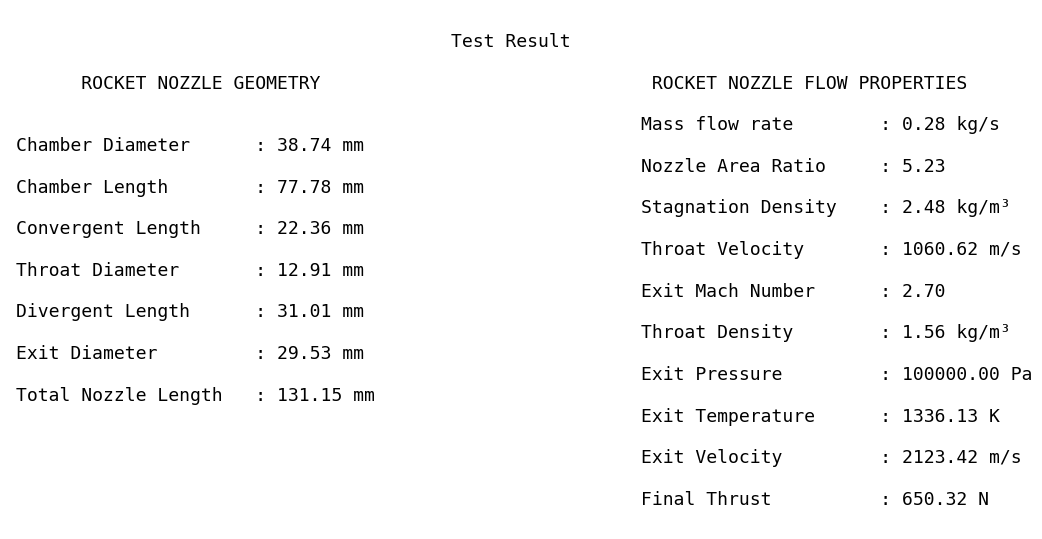

In [5]:
import matplotlib.pyplot as plt

# Geometry Report
geometry_report = f"""                                        Test Result

      ROCKET NOZZLE GEOMETRY


Chamber Diameter      : {cd_mm:.2f} mm

Chamber Length        : {lc_mm:.2f} mm

Convergent Length     : {conv_mm:.2f} mm

Throat Diameter       : {dt_mm:.2f} mm

Divergent Length      : {div_mm:.2f} mm

Exit Diameter         : {de_mm:.2f} mm

Total Nozzle Length   : {total_mm:.2f} mm
"""

# Flow Report
flow_report = f"""

 ROCKET NOZZLE FLOW PROPERTIES

Mass flow rate        : {m:.2f} kg/s

Nozzle Area Ratio     : {ar:.2f} 

Stagnation Density    : {ρ0:.2f} kg/m³

Throat Velocity       : {vt:.2f} m/s

Exit Mach Number      : {me:.2f}

Throat Density        : {ρt:.2f} kg/m³

Exit Pressure         : {ep:.2f} Pa

Exit Temperature      : {et:.2f} K

Exit Velocity         : {v_e:.2f} m/s

Final Thrust          : {F:.2f} N
"""

fig, ax = plt.subplots(1, 2, figsize=(12,6))

# Left panel
ax[0].axis("off")
ax[0].text(
    0.02,0.95,
    geometry_report,
    fontsize=13,
    va="top",
    family="monospace"
)

# Right panel
ax[1].axis("off")
ax[1].text(
    0.02,0.95,
    flow_report,
    fontsize=13,
    va="top",
    family="monospace"
)

# Reduce gap
plt.subplots_adjust(wspace=1.05)

plt.show()